### Importações e dependências
Esta primeira célula importa as bibliotecas usadas ao longo do notebook:
- `osmnx as ox`: API principal para baixar/operar com grafos OSM (obter ruas, converter em GeoDataFrames, plotar).
- `matplotlib.pyplot as plt`: para visualizar mapas/rotas e anotações.
- `geopandas`: manipulação de GeoDataFrames e operações espaciais.
- `networkx as nx`: algoritmos de grafos (Dijkstra, shortest_path, etc.).
- `from shapely.geometry import box`: utilitário para criar polígonos retangulares quando necessário.
Observação: O OSMnx integra bem NetworkX e GeoPandas — nodos/arestas do grafo carregado possuem atributos geográficos e métricos usados adiante.

In [1]:
import osmnx as ox
import matplotlib.pyplot as plt
import geopandas
import networkx as nx
from shapely.geometry import box

### Criação do grafo a partir de endereço/coordenadas
Esta célula cria `place_graph` a partir de coordenadas/endereços com `ox.graph_from_address`:
- `ox.graph_from_address("-23.543255, -46.642402", dist=1000, network_type="drive", simplify=True)` carrega a sub-rede de estradas num raio de 1000 metros em torno das coordenadas (lat, lon).
- `network_type='drive'` limita a ruas navegáveis por veículos; outros tipos incluem `walk`, `bike`, entre outros.
- `simplify=True` reduz nós desnecessários (colapsa nós de degree-2) para um grafo mais limpo.
- O resultado é um MultiDiGraph do NetworkX com nós e arestas contendo atributos OSM (como `length`, `highway`, `maxspeed`).

In [2]:
place_graph = ox.graph_from_address("-23.543255, -46.642402", dist=1000, network_type="drive", simplify=True)

### Primeiro plot do grafo (lat/lon)
Esta célula plota `place_graph` diretamente:
- `ox.plot_graph` desenha o grafo bruto carregado pela API `graph_from_address`.
- Parâmetros visuais controlam a aparência (cor das arestas, tamanho de nós, linewidth).

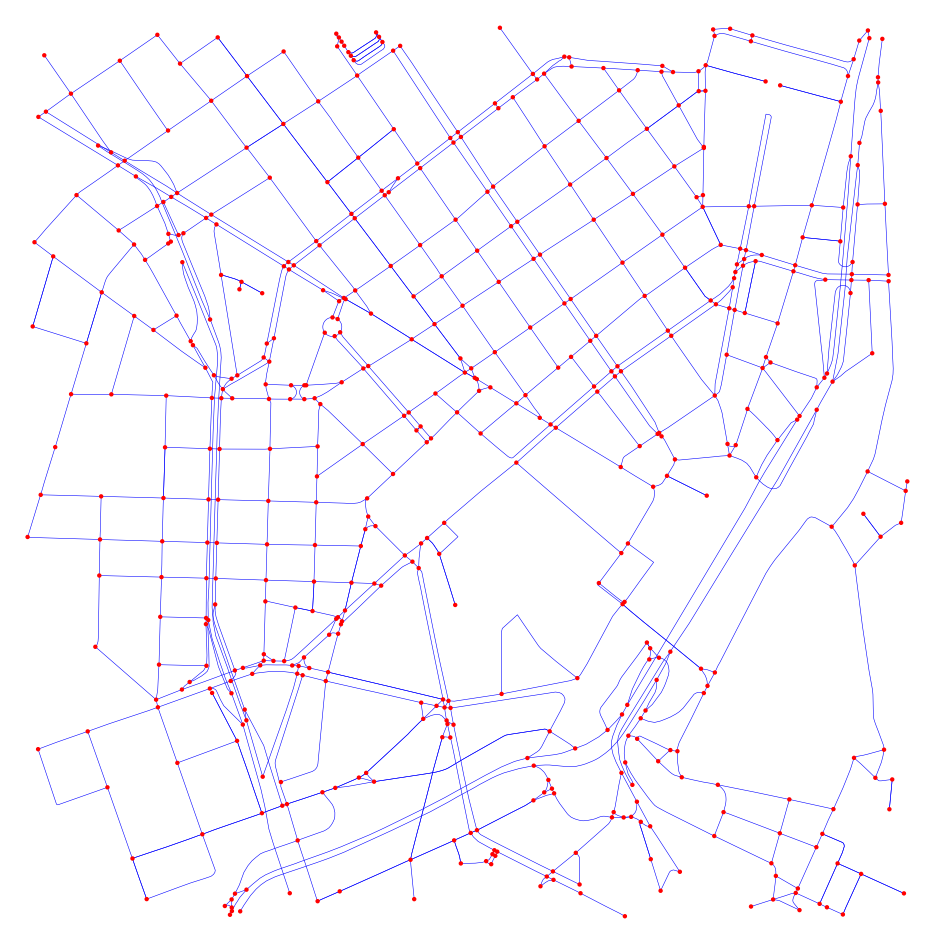

(<Figure size 1200x1200 with 1 Axes>, <Axes: >)

In [3]:
ox.plot_graph(place_graph, bgcolor="white", node_size=10, edge_color="blue", node_color="red", edge_linewidth=0.4, figsize=(12, 12), dpi=300)

### Conversão do grafo para GeoDataFrames
`gdf = ox.graph_to_gdfs(place_graph, edges=True, nodes=False)` converte o grafo em GeoDataFrames:
- Quando `edges=True` e `nodes=False` retorna um GeoDataFrame de arestas contendo geometria (LineString) e atributos como `length`, `highway`, `maxspeed` etc.
- Facilita análises e manipulações tabulares/espaciais usando GeoPandas.
- Aqui o objetivo é extrair atributos das arestas para calcular estatísticas e construir funções de peso.

In [4]:
gdf = ox.graph_to_gdfs(place_graph, edges=True, nodes=False)
gdf.head(2)

osmid      highway                     name  \
u        v         key                                                    
20944551 20944552  0      8307075  residential            Rua Fortunato   
         158844513 0    914039011     tertiary  Rua Frederico Abranches   

                        oneway reversed      length  \
u        v         key                                
20944551 20944552  0     False    False  164.142379   
         158844513 0      True    False  135.690412   

                                                                 geometry  \
u        v         key                                                      
20944551 20944552  0    LINESTRING (-46.65132 -23.53889, -46.65133 -23...   
         158844513 0    LINESTRING (-46.65132 -23.53889, -46.65119 -23...   

                       lanes maxspeed bridge tunnel width access junction  
u        v         key                                                     
20944551 20944552  0     NaN      NaN    NaN    NaN   NaN    NaN      NaN  
         158844513 0       2      NaN    NaN    NaN   NaN    NaN      NaN

In [5]:
features = geopandas.GeoDataFrame.from_features(gdf)
features.head(2)

,geometry,osmid,highway,name,oneway,reversed,length,lanes,maxspeed,bridge,tunnel,width,access,junction
0,"LINESTRING (-46.65132 -23.53889, -46.65133 -23...",8307075,residential,Rua Fortunato,False,False,164.142379,None,None,NaN,NaN,NaN,NaN,NaN
1,"LINESTRING (-46.65132 -23.53889, -46.65119 -23...",914039011,tertiary,Rua Frederico Abranches,True,False,135.690412,2,None,NaN,NaN,NaN,NaN,NaN


In [6]:
features.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 930 entries, 0 to 929
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   geometry  930 non-null    geometry
 1   osmid     930 non-null    object  
 2   highway   930 non-null    object  
 3   name      884 non-null    object  
 4   oneway    930 non-null    bool    
 5   reversed  930 non-null    object  
 6   length    930 non-null    float64 
 7   lanes     726 non-null    object  
 8   maxspeed  384 non-null    object  
 9   bridge    26 non-null     str     
 10  tunnel    17 non-null     str     
 11  width     5 non-null      str     
 12  access    20 non-null     str     
 13  junction  5 non-null      str     
dtypes: bool(1), float64(1), geometry(1), object(6), str(5)
memory usage: 95.5+ KB


In [7]:
features["maxspeed"].value_counts()

maxspeed
40          194
50          155
30           12
20            9
60            4
[40, 30]      4
[40, 50]      3
[50, 60]      1
[30, 20]      1
[30, 40]      1
Name: count, dtype: int64

### Estatísticas de comprimento
Esta célula calcula e imprime estatísticas descritivas básicas sobre a coluna `length` do GeoDataFrame de arestas:
- `min`, `max`, `mean`, `median` e `sum` são mostrados (usando `//1` para truncar a parte decimal na exibição).
- `length` nas arestas de grafos projetados é tipicamente em metros; estas medidas ajudam a entender a escala das ruas e validar unidades antes de usar tempos/velocidades.
- `Total length` fornece a soma de todos os comprimentos de aresta na subárea carregada — útil para estimativas rápidas de cobertura.

In [8]:
# print min, max, mean, median of length
print("Min length:", features['length'].min()//1, "meters")
print("Max length:", features['length'].max()//1, "meters")
print("Mean length:", features['length'].mean()//1, "meters")
print("Median length:", features['length'].median()//1, "meters")
print("Total length:", features['length'].sum()//1, "meters")

Min length: 2.0 meters
Max length: 893.0 meters
Mean length: 90.0 meters
Median length: 79.0 meters
Total length: 84116.0 meters


### Projeção do grafo
Esta célula chama `ox.project_graph(place_graph)` para transformar o grafo geográfico (lat/lon) para um CRS projetado (geralmente UTM) onde unidades são metros.
- Projeção é necessária para cálculos métricos acurados (comprimento de arestas, soma de distâncias).
- O OSMnx escolhe automaticamente um CRS apropriado para a área coberta pelo grafo quando `project_graph` é usado.
- `graph_proj` é usado subsequentemente em cálculos e plots que dependem de comprimentos em metros.

In [9]:
graph_proj = ox.project_graph(place_graph)

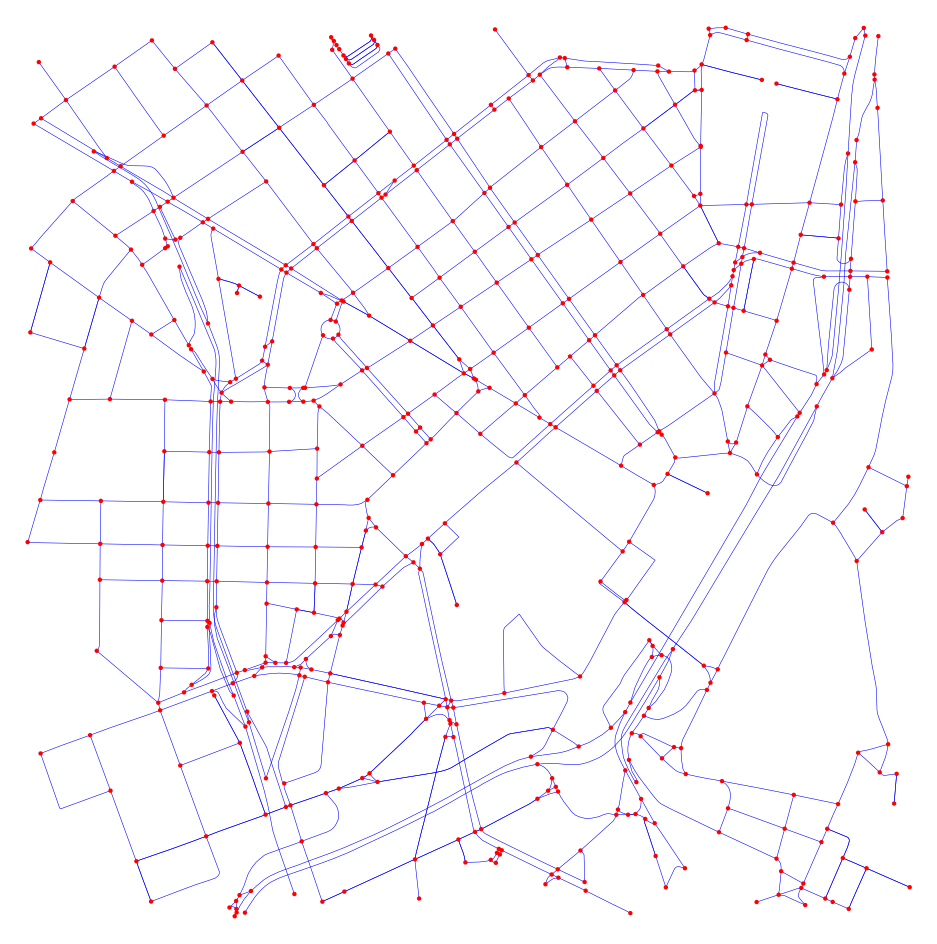

(<Figure size 1200x1200 with 1 Axes>, <Axes: >)

In [10]:
ox.plot_graph(graph_proj, bgcolor="white", node_size=10, edge_color="blue", node_color="red", edge_linewidth=0.4, figsize=(12, 12), dpi=300)

### Seleção aleatória de nós
Esta célula importa `random` e seleciona 5 nós aleatórios do grafo projetado:
- `random.sample(list(graph_proj.nodes()), 5)` transforma os nós em lista e escolhe 5 distintos.
- Esses nós serão usados como pontos de origem/destino para testes rápidos de rotas.
- Seleção aleatória é útil para demonstrações ou testes exploratórios; em produção escolheríamos nós com base em locais de interesse ou distribuídos espacialmente.

In [14]:
# faça um laço randomico de 0 a 5
import random
random_nodes = random.sample(list(graph_proj.nodes()), 5)

### Funções de peso e cálculo de tempo
Esta célula contém duas funções: `calculate_weight(d)` e `weight_function(u, v, d)`. Explicação passo-a-passo:
1) Objetivo geral: calcular um custo/tempo para uma aresta baseado em `length` (metros) e `maxspeed` (km/h), retornando tempo em segundos.
2) `calculate_weight(d)`
   - `length = d.get('length')` captura o comprimento da aresta em metros (valor float).
   - `maxspeed = d.get('maxspeed', 40')` tenta obter o limite de velocidade; se não estiver presente, assume 40 km/h como padrão.
   - Tratamento de formatos:
     - Se `maxspeed` for uma lista (caso OSM tenha múltiplos valores), pega-se o menor valor numérico: `min([float(x) for x in maxspeed if numeric(x)])` — isso é conservador pois escolhe a velocidade mínima entre os informados.
     - Se for string, tenta converter para float; se não for numérico, usa 40 km/h padrão.
     - Caso seja um número já, converter para float.
   - Redução por comprimento: o código aplica um `reduction_factor` que diminui a velocidade em ruas muito curtas:
     - Fórmula usada: reduction_factor = 1 - min(0.5, 50 / max(length, 1) * 0.5)
     - Interpretação: para ruas muito curtas (length pequeno) a velocidade é reduzida até 50% (multiplicador entre 0.5 e 1). A expressão `50 / max(length,1)` cresce quando length é pequeno; multiplicando por 0.5 e com teto em 0.5, limita a redução máxima a 50%.
   - `adjusted_speed = maxspeed * reduction_factor` aplica a redução à velocidade nominal.
   - Conversão de unidades: a expressão final calcula tempo em segundos: `length / (adjusted_speed * 1000 / 3600)`
     - Porque `maxspeed` está em km/h; multiplicando por 1000/3600 convertemos para m/s.
     - Tempo (s) = distância (m) / velocidade (m/s).
3) `weight_function(u, v, d)`
   - Em grafos OSMnx, `d` pode ser:
     - um dicionário simples com atributos da aresta, ou
     - um dicionário mapeando chaves (IDs de arestas) para subdicionários (quando há múltiplas arestas entre os mesmos nós).
   - A função verifica o tipo e, se for um dicionário de subdicionários, calcula o tempo (`calculate_weight`) para cada sub-aresta e armazena em `weight`.
   - No fim retorna a média (`sum(weight)/len(weight)`) — isto significa que, quando existem múltiplas arestas paralelas, usamos o tempo médio como custo representativo.

In [12]:
def calculate_weight(d):
    length = d.get('length') # em metros
    maxspeed = d.get('maxspeed', 40) # em km/h
    # Se for lista, pega o menor valor e converte para float
    if isinstance(maxspeed, list):
        maxspeed = min([float(x) for x in maxspeed if str(x).replace('.', '', 1).isdigit()])
    # Se for string, converte para float
    elif isinstance(maxspeed, str):
        if maxspeed.replace('.', '', 1).isdigit():
            maxspeed = float(maxspeed)
        else:
            maxspeed = 40  # valor padrão se não for número
    # Se não, tenta converter para float
    else:
        maxspeed = float(maxspeed)
    # Redução: quanto menor o length, maior a redução de velocidade
    # Exemplo: redução de até 50% para ruas curtas (<50m)
    reduction_factor = 1 - min(0.5, 50 / max(length, 1) * 0.5)  # ajuste conforme necessário
    adjusted_speed = maxspeed * reduction_factor
    return length/(max(adjusted_speed, 1) * 1000 / 3600) # tempo = distancia / velocidade em segundos

def weight_function(u, v, d):
    """Calcula o peso de uma aresta usando length e maxspeed, com redução para ruas curtas."""
    weight = []
    # se d é um dicionario de dicionarios, precisamos efetuar o calculo para cada subdicionario
    if isinstance(d, dict):
        # se for um dicionario de dicionarios, precisamos iterar sobre os subdicionarios
        for key in d:
            sub_d = d[key]
            weight.append(calculate_weight(sub_d)) # tempo = distancia / velocidade
    # se d é um dicionario simples, podemos efetuar o calculo diretamente
    else:
        weight.append(calculate_weight(d)) # tempo = distancia / velocidade
    return sum(weight)/len(weight) # calcular o tempo médio

### Geração e plot do caminho mais curto
Esta célula calcula um caminho mais curto entre dois nós usando `nx.shortest_path` com `weight=weight_function` e o plota:
- `nx.shortest_path(graph_proj, source, target, weight=weight_function)` encontra o caminho que minimiza a soma dos pesos retornados por `weight_function` (no nosso caso, interpretado como tempo em segundos).
- Em grafos com múltiplas arestas entre os mesmos nós, a função de peso é chamada para cada aresta; como `weight_function` trata dicionários e múltiplos sub-dicionários, ela retorna o tempo médio quando existem várias arestas paralelas.
- O resultado é passado para `ox.plot_graph_route` que desenha o caminho destacado sobre o grafo projetado.

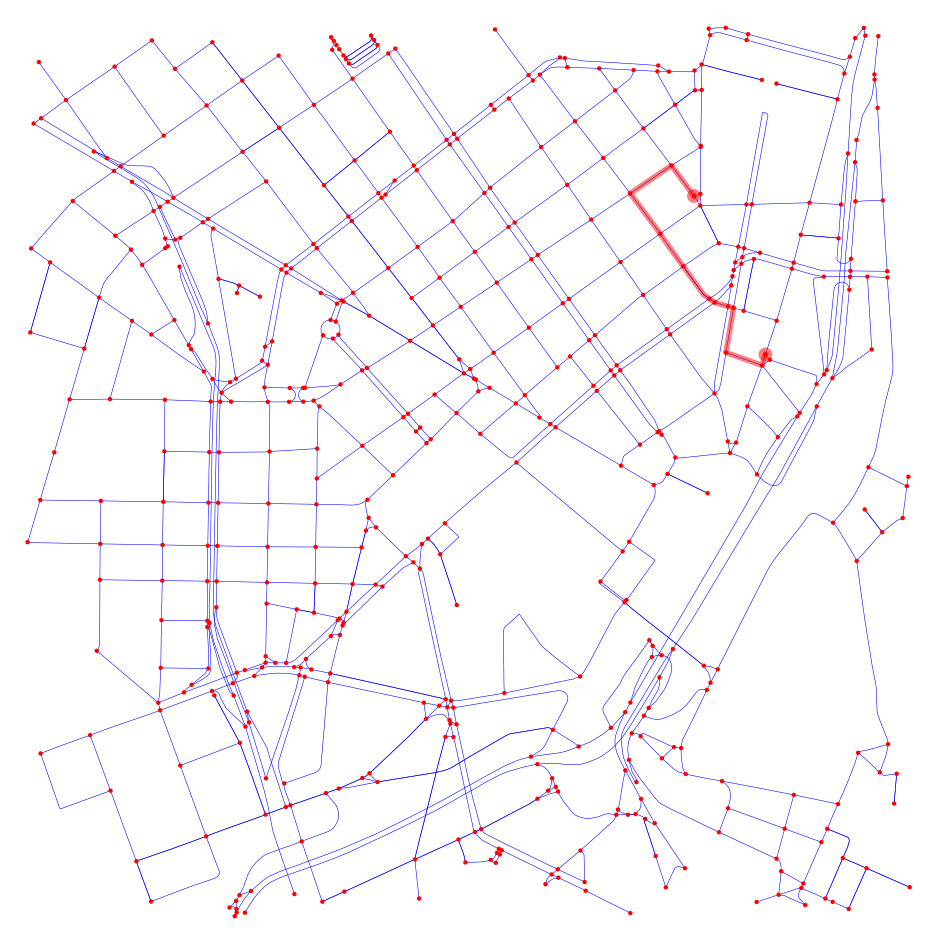

In [15]:
route = nx.shortest_path(graph_proj, random_nodes[1], random_nodes[2], weight=weight_function)
fig, ax = ox.plot_graph_route(graph_proj, route, bgcolor="white", node_size=10, edge_color="blue", node_color="red", edge_linewidth=0.4, figsize=(12, 12), dpi=300)

### Função path_weight_sum
Esta função soma pesos ao longo de um caminho (lista de nós):
- Recebe `graph`, `path` (lista de nós) e `weight` (nome do atributo de aresta a somar, por padrão `'length'`).
- Itera sobre pares consecutivos de nós `(u, v)` e obtém os dados da aresta com `graph.get_edge_data(u, v)`.
- Como em grafos rodoviários do OSMnx pode existir múltiplas arestas entre os mesmos nós (multigrafo), o código trata `edge_data` quando é um dicionário de múltiplas arestas: pega a primeira (`list(edge_data.values())[0]`).
- Soma o valor do campo `weight` de cada aresta (por exemplo `length` em metros) e retorna o total.
Uso: útil para obter o comprimento total de um segmento de rota encontrado por Dijkstra.

In [16]:
def path_weight_sum(graph, path, weight='length'):
    total = 0
    for u, v in zip(path[:-1], path[1:]):
        edge_data = graph.get_edge_data(u, v)
        if isinstance(edge_data, dict):
            # Caso haja múltiplas arestas, pega a primeira
            edge = list(edge_data.values())[0]
        else:
            edge = edge_data
        total += edge.get(weight, 0)
    return total

### Função plot_route_with_eta
Esta célula define a função `plot_route_with_eta(graph, route, weight_function)` que:
- Percorre a sequência de nós em `route` e, para cada par de nós consecutivos, calcula o menor caminho entre eles usando `nx.bidirectional_dijkstra` com a `weight_function` definida anteriormente.
- `bidirectional_dijkstra` retorna (peso_total, caminho_encontrado). Aqui o peso corresponde ao custo acumulado segundo a função de peso (neste notebook, tempo em segundos).
- Para cada segmento ele:
  - calcula ETA do segmento (valor retornado por Dijkstra) e o comprimento do segmento chamando `path_weight_sum`.
  - acumula ETA e comprimento totais.
  - plota o segmento sobre um eixo Matplotlib já carregado com o grafo base (chamando `ox.plot_graph_route` com `ax=ax`).
  - anota no mapa o ETA (convertido para minutos) e comprimento em metros aproximados, posicionando o texto no nó médio do segmento.
- Gera uma legenda colorida usando um colormap (`tab10`) e adiciona um painel com ETA total e comprimento total no canto superior esquerdo.
Observações de implementação:
- A função usa `show=False, close=False` para desenhar incrementalmente no mesmo eixo.
- A unidade retornada pela função de peso é tratada como segundos; quando convertido para minutos, divide-se por 60 para exibir na anotação.
- `path_weight_sum` é usada para somar pesos de arestas (por padrão, soma `length` em metros).
- O fechamento do ciclo (`end = route[(i + 1) % num_segments]`) faz com que, quando `route` for uma lista de N nós, também calcule o segmento final de volta ao primeiro nó — útil para rotas cíclicas.

In [17]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

def plot_route_with_eta(graph, route, weight_function):
    total_eta = 0
    total_length = 0

    # Gera cores diferentes para cada segmento
    num_segments = len(route)
    colors = plt.get_cmap('tab10', num_segments)

    fig, ax = ox.plot_graph(graph, bgcolor="white", node_size=10, edge_color="gray", node_color="red", edge_linewidth=0.4, figsize=(12, 12), dpi=300, show=False, close=False)

    for i in range(num_segments):
        start = route[i]
        end = route[(i + 1) % num_segments]  # fecha o ciclo
        eta, segment = nx.bidirectional_dijkstra(graph, start, end, weight=weight_function)
        length = path_weight_sum(graph, segment)
        total_eta += eta
        total_length += length
        color = mcolors.to_hex(colors(i))
        # Plota o segmento
        ox.plot_graph_route(
            graph, segment, route_color=color, route_linewidth=3,
            ax=ax, orig_dest_node_color='none', show=False, close=False
        )
        # Pega o ponto do meio do segmento para a legenda
        mid_idx = len(segment) // 2
        mid_node = segment[mid_idx]
        x = graph.nodes[mid_node]['x']
        y = graph.nodes[mid_node]['y']
        ax.text(x, y, f"{eta/60:.1f} min - {length:.1f} m", color=color, fontsize=10, bbox=dict(facecolor='white', alpha=0.7))

    # Cria legenda
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], color=mcolors.to_hex(colors(i)), lw=3, label=f"Segmento {i+1}") for i in range(num_segments)
    ]
    ax.legend(handles=legend_elements, loc='best')
    # Adiciona total ETA e total length no canto superior esquerdo
    ax.text(
        0.01, 0.99,
        f"ETA total: {total_eta/60:.1f} min\nLength total: {total_length:.1f} m",
        transform=ax.transAxes,
        fontsize=10,
        verticalalignment='top',
        bbox=dict(facecolor='white', alpha=0.8)
    )
    plt.show()

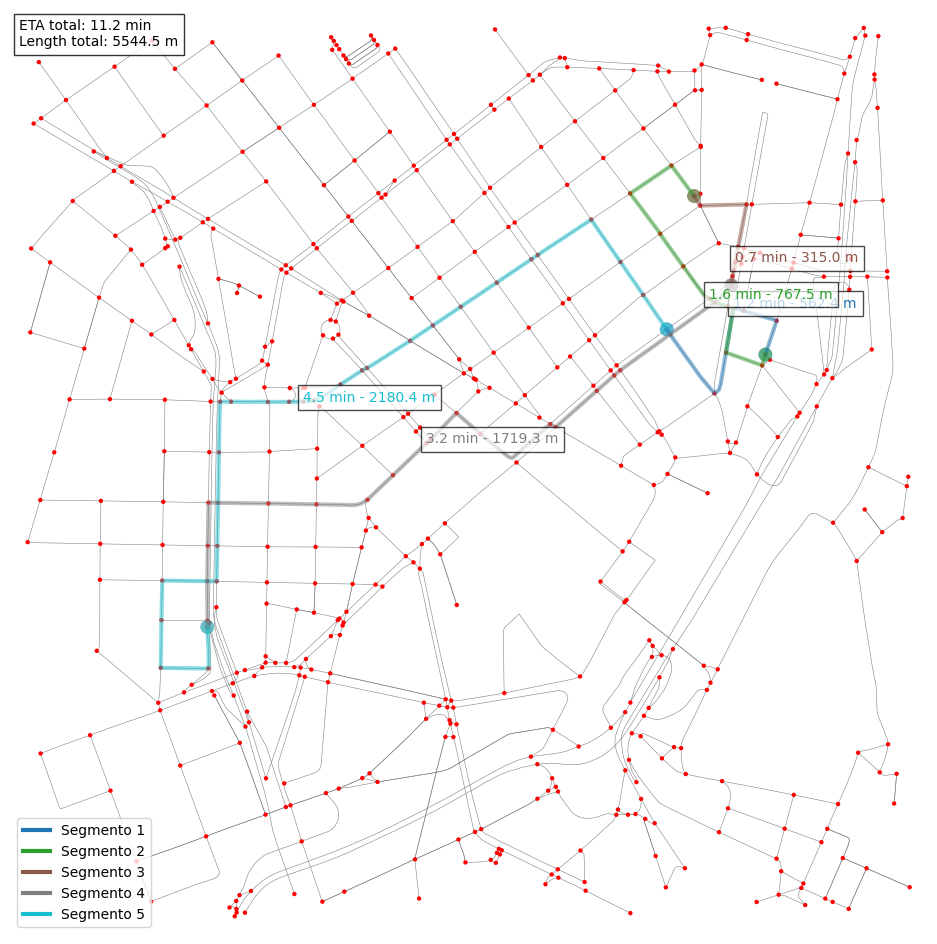

In [18]:
plot_route_with_eta(graph_proj, random_nodes, weight_function)

### Explicação da chamada de plot (variações)
Esta célula chama a função plot_route_with_eta usando uma nova permutação aleatória dos nós.
- Permuta os nós com random.sample para testar rotas alternativas.
- A função calcula ETA por segmento (em segundos) e desenha legendas e textos sobre o mapa.
- Serve para validar consistência entre execuções.

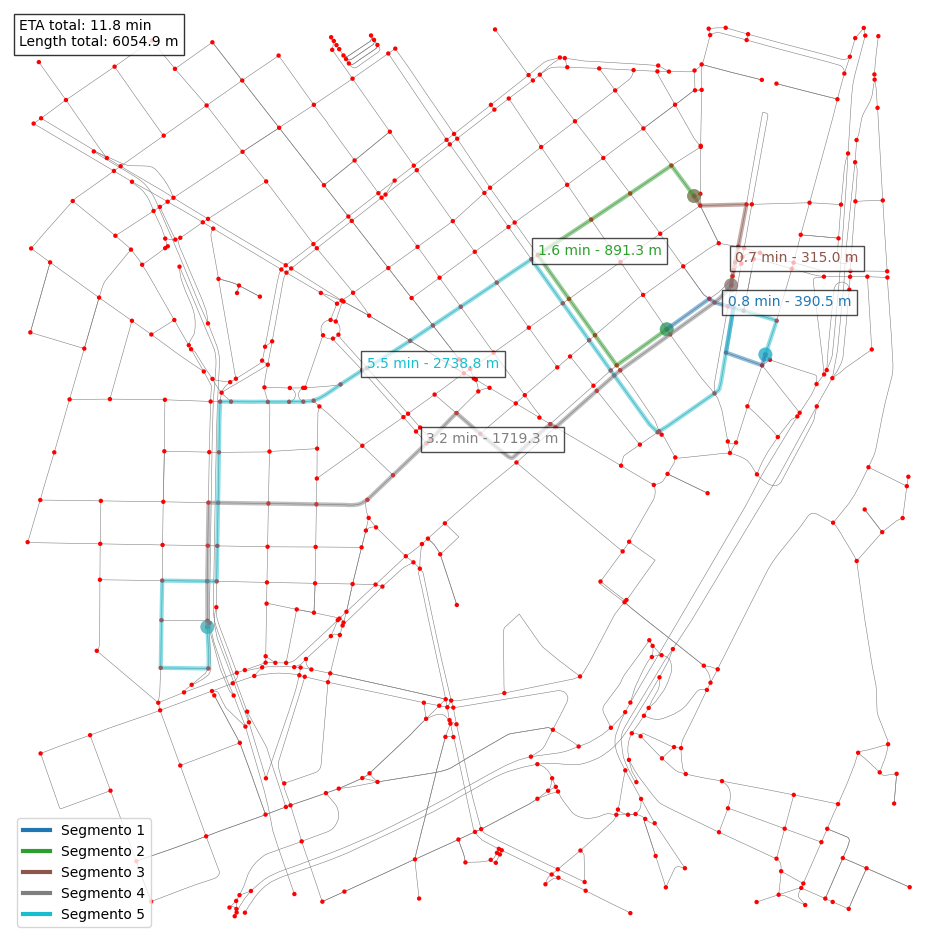

In [19]:
plot_route_with_eta(graph_proj, random.sample(random_nodes, len(random_nodes)), weight_function)

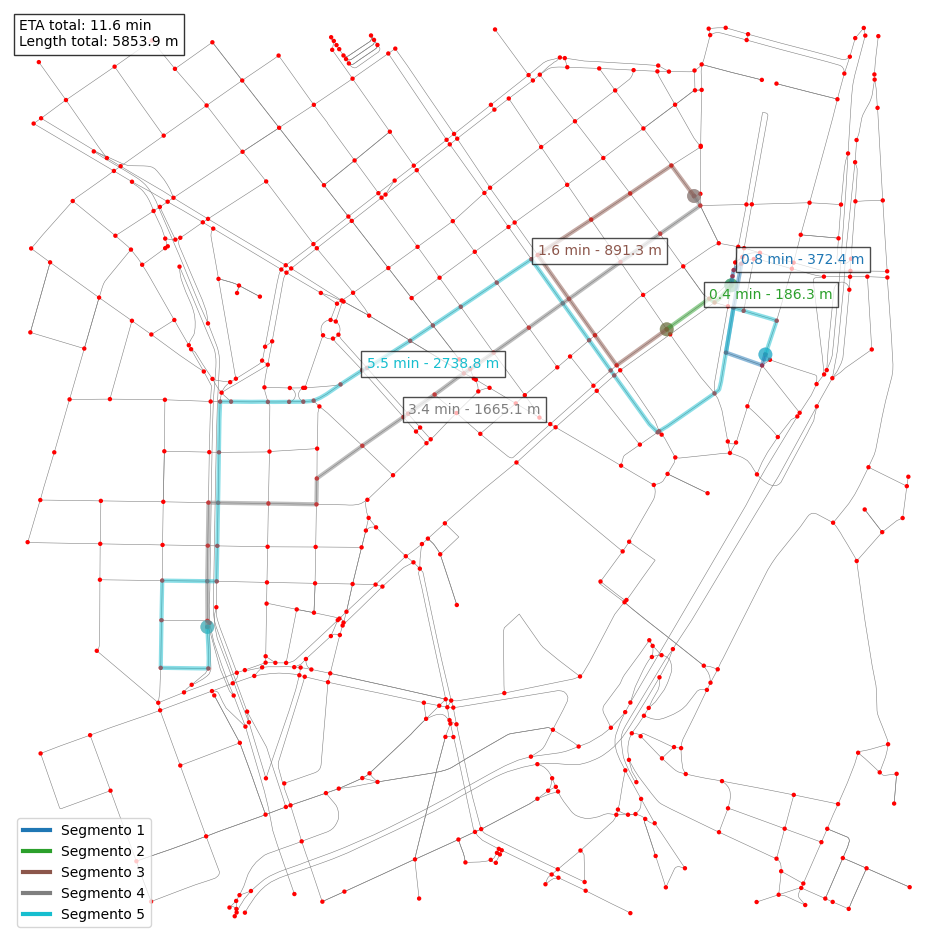

In [20]:
plot_route_with_eta(graph_proj, random.sample(random_nodes, len(random_nodes)), weight_function)